In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device:{device}")

Using Device:cuda


In [ ]:
df = pd.read_csv('fmnist_small.csv')

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


# Basic Graph

In [ ]:
fruits =["Apple","Banana","Mango"]

for index,fruit in enumerate(fruits):
  print(index,fruit)

0 Apple
1 Banana
2 Mango


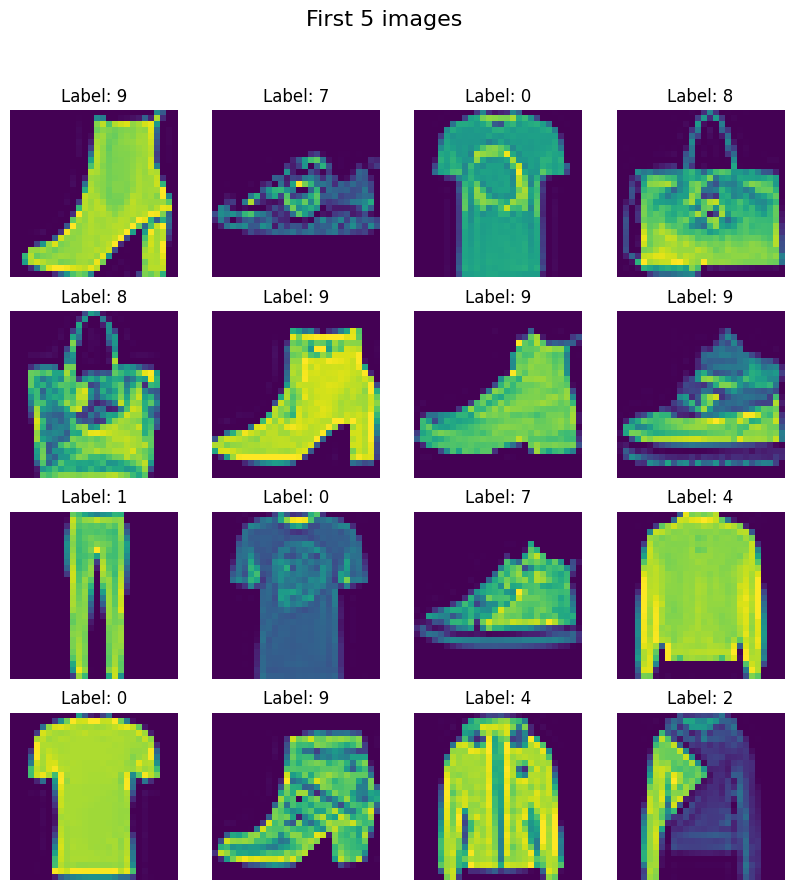

In [ ]:
fig ,axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 5 images",fontsize=16)

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')

  ax.set_title(f"Label: {df.iloc[i,0]}")
#

In [ ]:
len(df.columns)

785

In [ ]:
len(df['label'].unique())

10

In [ ]:
len(df.iloc[:,1:])

6000

In [ ]:
#train test split

X = df.iloc[:,1:].values
y = df.iloc[:,0].values


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#scaling the features

X_train = X_train/255.0
X_test = X_test/255.0
# y_train should not be scaled as it contains class labels (integers)

# Custome Dataset

In [ ]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    x = self.features[index]
    y = self.labels[index]
    return x,y

In [ ]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [ ]:
len(train_dataset)
#

4800

In [ ]:
len(test_dataset)

1200

In [ ]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

# Define NN Class


In [ ]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10),

    )

  def forward(self,X):
    return self.model(X)


# Instantiate Model

In [ ]:
epochs = 50
learning_rate = 0.1

In [ ]:
model = MyNN(X_train.shape[1])
model = model.to(device)


In [ ]:
#Loss function CCE
criterion = nn.CrossEntropyLoss()


In [ ]:
#optimizers
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [ ]:
len(train_loader)

150

In [ ]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features,batch_labels in train_loader:

    #move data to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    #forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output,batch_labels)

    #back pass
    optimizer.zero_grad()
    loss.backward()

    #update
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss / len(train_loader)

  print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss}")

Epoch 1/50, Average Loss: 1.3216368587811789
Epoch 2/50, Average Loss: 0.779336541891098
Epoch 3/50, Average Loss: 0.6427524608373641
Epoch 4/50, Average Loss: 0.5751657414436341
Epoch 5/50, Average Loss: 0.5278772541880608
Epoch 6/50, Average Loss: 0.49531100074450174
Epoch 7/50, Average Loss: 0.46192684868971506
Epoch 8/50, Average Loss: 0.4355265040695667
Epoch 9/50, Average Loss: 0.41890643616517387
Epoch 10/50, Average Loss: 0.39741520086924237
Epoch 11/50, Average Loss: 0.38665723502635957
Epoch 12/50, Average Loss: 0.37127780785163245
Epoch 13/50, Average Loss: 0.34902072985967
Epoch 14/50, Average Loss: 0.3476298343638579
Epoch 15/50, Average Loss: 0.315855147143205
Epoch 16/50, Average Loss: 0.31195787360270816
Epoch 17/50, Average Loss: 0.2958236853778362
Epoch 18/50, Average Loss: 0.2882651568452517
Epoch 19/50, Average Loss: 0.2712535865108172
Epoch 20/50, Average Loss: 0.2599384474754334
Epoch 21/50, Average Loss: 0.2577110414206982
Epoch 22/50, Average Loss: 0.24670669116

# Evaluation

In [ ]:
temp = torch.tensor([
    [0.2,0.1,0.7],
    [0.5,0.3,0.2]
])

_,predicted=torch.max(temp,dim=1)
#
print(_)
print(predicted)

tensor([0.7000, 0.5000])
tensor([2, 0])


In [ ]:
model.eval()

total= 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    #move data to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = model(batch_features)
    # print(f"Outputs,{outputs}"")
    _,predicted = torch.max(outputs,dim=1)
    print(predicted)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()



print(f"Total num:, {total}")
print(f"Correct num:, {correct}")
print(f"Accuracy:, {correct/total}")

tensor([7, 0, 5, 6, 3, 4, 5, 4, 9, 7, 0, 6, 4, 0, 5, 1, 7, 7, 6, 0, 4, 0, 2, 0,
        9, 0, 9, 4, 0, 1, 5, 6], device='cuda:0')
tensor([4, 8, 1, 6, 9, 3, 9, 4, 8, 5, 3, 1, 2, 3, 8, 9, 9, 9, 5, 0, 4, 0, 0, 4,
        1, 4, 8, 4, 2, 3, 0, 8], device='cuda:0')
tensor([6, 1, 4, 1, 4, 7, 6, 8, 0, 1, 8, 2, 3, 2, 4, 9, 1, 3, 7, 9, 4, 6, 4, 7,
        0, 4, 1, 3, 4, 1, 6, 4], device='cuda:0')
tensor([8, 3, 7, 1, 6, 5, 4, 2, 8, 7, 0, 5, 6, 5, 2, 4, 7, 9, 9, 7, 1, 6, 6, 6,
        1, 7, 1, 9, 7, 2, 0, 5], device='cuda:0')
tensor([6, 3, 5, 7, 9, 1, 9, 1, 5, 7, 1, 1, 5, 0, 1, 1, 9, 8, 0, 3, 3, 9, 8, 9,
        4, 4, 2, 6, 2, 6, 5, 2], device='cuda:0')
tensor([3, 2, 5, 4, 8, 4, 3, 8, 5, 9, 2, 0, 6, 4, 1, 5, 9, 9, 8, 5, 9, 2, 4, 5,
        0, 9, 1, 2, 4, 1, 4, 6], device='cuda:0')
tensor([4, 3, 6, 8, 3, 3, 3, 6, 2, 6, 1, 2, 7, 7, 0, 9, 1, 3, 2, 7, 9, 6, 2, 6,
        0, 0, 9, 7, 1, 9, 0, 3], device='cuda:0')
tensor([7, 1, 6, 9, 9, 0, 5, 1, 7, 0, 8, 2, 7, 6, 7, 3, 3, 7, 6, 2, 3, 5, 9, 4,
        4,